# Freight Rate Prediction — Data Profiling

## 1. Objective

This notebook documents the exploratory data analysis and data-quality investigation for the Spotter Labs Freight Rate Machine Learning Assessment.

The development dataset (`train-test.csv`) contains labeled historical freight loads with `posted_rate` as the prediction target. The validation dataset (`validation.csv`) contains future loads for which rates must be predicted. The December input dataset (`december-chart-inputs.csv`) is used for the required December prediction chart.

The objective of this stage is to understand the structure, quality, temporal characteristics, feature availability, and potential limitations of the data before making decisions about validation strategy, feature engineering, and model selection.

No source data will be modified during profiling.

## 2. Dataset Loading

Load the three supplied datasets without modifying their contents. The initial inspection will verify their dimensions and available columns.

In [1]:
import pandas as pd

train = pd.read_csv("../data/train-test.csv")
validation = pd.read_csv("../data/validation.csv")
december = pd.read_csv("../data/december-chart-inputs.csv")

print("Train/Test shape:", train.shape)
print("Validation shape:", validation.shape)
print("December inputs shape:", december.shape)

print("\nTrain/Test columns:")
print(train.columns.tolist())

print("\nValidation columns:")
print(validation.columns.tolist())

print("\nDecember inputs columns:")
print(december.columns.tolist())

Train/Test shape: (48000, 14)
Validation shape: (12000, 13)
December inputs shape: (31, 7)

Train/Test columns:
['load_id', 'pickup', 'delivery', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'weight', 'date', 'market_index', 'quote_signal', 'posted_rate']

Validation columns:
['load_id', 'pickup', 'delivery', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'weight', 'date', 'market_index', 'quote_signal']

December inputs columns:
['pickup', 'delivery', 'distance', 'equipment', 'weight', 'date', 'predicted_rate']


## 3. Initial Data Integrity Checks

This section examines data types, missing values, duplicate records, duplicate identifiers, and the temporal coverage of each dataset.

These checks are performed before any cleaning or feature engineering so that potential data-quality issues can be documented before decisions are made.

In [4]:
print("=== MISSING VALUES ===")

train_missing = train.isna().sum()
validation_missing = validation.isna().sum()
december_missing = december.isna().sum()

print("\nTrain:")
print(train_missing[train_missing > 0].to_string())

print("\nValidation:")
print(validation_missing[validation_missing > 0].to_string())

print("\nDecember:")
print(december_missing[december_missing > 0].to_string())


print("\n=== DUPLICATE ROWS ===")
print(f"Train:      {train.duplicated().sum()}")
print(f"Validation: {validation.duplicated().sum()}")
print(f"December:   {december.duplicated().sum()}")


print("\n=== DUPLICATE LOAD IDs ===")
print(f"Train:      {train['load_id'].duplicated().sum()}")
print(f"Validation: {validation['load_id'].duplicated().sum()}")


print("\n=== DATE RANGES ===")
print(f"Train:       {train['date'].min()} → {train['date'].max()}")
print(f"Validation:  {validation['date'].min()} → {validation['date'].max()}")
print(f"December:    {december['date'].min()} → {december['date'].max()}")

=== MISSING VALUES ===

Train:
weight          300
market_index    374

Validation:
weight          165
market_index    249

December:
predicted_rate    31

=== DUPLICATE ROWS ===
Train:      0
Validation: 0
December:   0

=== DUPLICATE LOAD IDs ===
Train:      0
Validation: 0

=== DATE RANGES ===
Train:       2025-01-01 → 2025-10-31
Validation:  2025-11-01 → 2025-12-31
December:    2025-12-01 → 2025-12-31


## 3.1 Initial Data Integrity Findings

The initial integrity checks identified the following:

- The development dataset contains 48,000 records and the validation dataset contains 12,000 records.
- The development data covers 2025-01-01 through 2025-10-31.
- The validation data covers 2025-11-01 through 2025-12-31, making it temporally later than the development data.
- The December chart inputs cover all 31 days from 2025-12-01 through 2025-12-31.
- There are no duplicate rows in the development, validation, or December input datasets.
- There are no duplicate `load_id` values in either the development or validation datasets.
- The development dataset has 300 missing `weight` values and 374 missing `market_index` values.
- The validation dataset has 165 missing `weight` values and 249 missing `market_index` values.
- The December chart input dataset has 31 missing `predicted_rate` values. These are expected because `predicted_rate` is the value that the model is required to generate.
- No source data has been modified at this stage.

## 4. Numerical Feature and Target Investigation

Before deciding on cleaning or feature engineering, we will inspect the distributions and ranges of the numerical variables.

The purpose is to identify unusual, invalid, or potentially influential values without assuming in advance that an unusual value is erroneous.

In [5]:
numeric_columns = [
    "distance",
    "weight",
    "market_index",
    "quote_signal",
    "posted_rate"
]

train[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
distance,48000.0,1135.856654,728.564416,70.00000,550.40000,953.30000,1645.525000,3439.80000
weight,47700.0,31028.844004,9391.440620,-47500.00000,25800.00000,31436.50000,37018.000000,47500.00000
market_index,47626.0,1.083387,0.168091,0.67639,0.94967,1.05580,1.219590,1.46778
quote_signal,48000.0,2.062468,0.291391,0.69228,1.89103,2.05575,2.221685,3.61035
posted_rate,48000.0,2373.980682,1486.493245,57.22000,1251.55500,2030.76000,3330.750000,25533.00000


## 4.1 Numerical Profiling Findings

The numerical summary shows several characteristics requiring further investigation:

- `distance` ranges from 70 to 3,439 miles.
- `weight` contains missing values and has a negative minimum value of -47,500. The negative observations will be investigated before deciding how they should be handled.
- `market_index` contains missing values and has an observed range of approximately 0.68 to 1.47.
- `quote_signal` has no missing values in the development dataset and ranges from approximately 0.69 to 3.61.
- `posted_rate` ranges from 57.22 to 25,533, with a median of approximately 2,030.76. The distribution will be examined further to determine whether the upper values represent legitimate observations or potential outliers.

No observations are removed or transformed based solely on these summary statistics.

## 5. Suspicious and Potentially Invalid Values

Summary statistics identified potentially unusual values, particularly negative `weight` observations. This section examines their frequency and magnitude before any data-cleaning decision is made.

In [7]:
print("=== WEIGHT ===")
print(f"Negative: {(train['weight'] < 0).sum()}")
print(f"Zero:     {(train['weight'] == 0).sum()}")
print(f"Positive: {(train['weight'] > 0).sum()}")
print(f"Missing:  {train['weight'].isna().sum()}")

print("\n=== DISTANCE ===")
print(f"Negative: {(train['distance'] < 0).sum()}")
print(f"Zero:     {(train['distance'] == 0).sum()}")
print(f"Positive: {(train['distance'] > 0).sum()}")
print(f"Missing:  {train['distance'].isna().sum()}")

print("\n=== POSTED RATE ===")
print(f"Negative: {(train['posted_rate'] < 0).sum()}")
print(f"Zero:     {(train['posted_rate'] == 0).sum()}")
print(f"Positive: {(train['posted_rate'] > 0).sum()}")
print(f"Missing:  {train['posted_rate'].isna().sum()}")

print("\n=== POSTED RATE PERCENTILES ===")
percentiles = [0, 0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 1.00]
print(train["posted_rate"].quantile(percentiles).to_string())

=== WEIGHT ===
Negative: 292
Zero:     0
Positive: 47408
Missing:  300

=== DISTANCE ===
Negative: 0
Zero:     0
Positive: 48000
Missing:  0

=== POSTED RATE ===
Negative: 0
Zero:     0
Positive: 48000
Missing:  0

=== POSTED RATE PERCENTILES ===
0.00       57.2200
0.01      327.1688
0.05      599.7385
0.25     1251.5550
0.50     2030.7600
0.75     3330.7500
0.95     4953.7665
0.99     5972.8340
1.00    25533.0000


## 5.1 Suspicious Value Findings

The numerical validity checks show:

- `distance` contains 48,000 positive observations and no zero, negative, or missing values.
- `posted_rate` contains 48,000 positive observations and no zero, negative, or missing values.
- `weight` contains 47,408 positive observations, 292 negative observations, and 300 missing observations.
- The negative `weight` values range from -5,000 to -47,500.
- `posted_rate` is positively skewed. The 99th percentile is approximately 5,972.83, while the maximum is 25,533.
- The unusual `weight` and `posted_rate` observations require further investigation before any cleaning or transformation decisions are made.

No observations have been removed or modified.

## 5.2 Investigation of Negative Weight Records

The development dataset contains 292 negative `weight` values. Before determining how these records should be handled, their other characteristics will be examined to determine whether the negative sign is associated with a particular equipment type, route, distance, rate, or other pattern.

In [8]:
negative_weight = train[train["weight"] < 0].copy()

print("Number of negative-weight records:", len(negative_weight))

print("\n=== EQUIPMENT ===")
print(negative_weight["equipment"].value_counts().to_string())

print("\n=== WEIGHT SUMMARY ===")
print(negative_weight["weight"].describe().to_string())

print("\n=== DISTANCE SUMMARY ===")
print(negative_weight["distance"].describe().to_string())

print("\n=== POSTED RATE SUMMARY ===")
print(negative_weight["posted_rate"].describe().to_string())

print("\n=== SAMPLE RECORDS ===")
print(
    negative_weight[
        [
            "load_id",
            "pickup",
            "delivery",
            "distance",
            "equipment",
            "weight",
            "market_index",
            "quote_signal",
            "posted_rate",
        ]
    ].head(10).to_string(index=False)
)

Number of negative-weight records: 292

=== EQUIPMENT ===
equipment
Dry Van    155
Flatbed     70
Reefer      67

=== WEIGHT SUMMARY ===
count      292.000000
mean    -31724.195205
std       8262.536326
min     -47500.000000
25%     -37284.250000
50%     -31821.500000
75%     -25928.500000
max      -5000.000000

=== DISTANCE SUMMARY ===
count     292.000000
mean     1120.920205
std       733.132047
min        75.100000
25%       531.975000
50%       930.450000
75%      1537.125000
max      3161.700000

=== POSTED RATE SUMMARY ===
count      292.000000
mean      2389.786233
std       1641.761285
min        247.370000
25%       1257.410000
50%       1994.960000
75%       3185.257500
max      14561.210000

=== SAMPLE RECORDS ===
  load_id      pickup     delivery  distance equipment   weight  market_index  quote_signal  posted_rate
TR-000069    Amarillo       Dayton    1334.2    Reefer -36559.0       0.96102       2.11777      2831.27
TR-000205      Fresno       Tucson     496.2   Dry Van

In [9]:
print("=== NEGATIVE-WEIGHT TARGET ===")

print("Posted-rate summary:")
print(
    negative_weight["posted_rate"]
    .describe()
    .to_string()
)

print("\nPosted-rate percentiles:")
print(
    negative_weight["posted_rate"]
    .quantile([0, 0.25, 0.50, 0.75, 0.95, 0.99, 1.00])
    .to_string()
)

print("\nMissing values within negative-weight records:")
print(
    negative_weight.isna().sum()[
        negative_weight.isna().sum() > 0
    ].to_string()
)

=== NEGATIVE-WEIGHT TARGET ===
Posted-rate summary:
count      292.000000
mean      2389.786233
std       1641.761285
min        247.370000
25%       1257.410000
50%       1994.960000
75%       3185.257500
max      14561.210000

Posted-rate percentiles:
0.00      247.3700
0.25     1257.4100
0.50     1994.9600
0.75     3185.2575
0.95     5158.1500
0.99     6008.4402
1.00    14561.2100

Missing values within negative-weight records:
market_index    3


In [10]:
print("=== ABSOLUTE WEIGHT COMPARISON ===")

positive_weight = train[train["weight"] > 0].copy()

print("Negative weight absolute-value summary:")
print(
    negative_weight["weight"].abs().describe().to_string()
)

print("\nPositive weight summary:")
print(
    positive_weight["weight"].describe().to_string()
)

print("\nNegative-weight absolute-value percentiles:")
print(
    negative_weight["weight"].abs()
    .quantile([0, 0.25, 0.50, 0.75, 0.95, 0.99, 1.00])
    .to_string()
)

print("\nPositive-weight percentiles:")
print(
    positive_weight["weight"]
    .quantile([0, 0.25, 0.50, 0.75, 0.95, 0.99, 1.00])
    .to_string()
)

=== ABSOLUTE WEIGHT COMPARISON ===
Negative weight absolute-value summary:
count      292.000000
mean     31724.195205
std       8262.536326
min       5000.000000
25%      25928.500000
50%      31821.500000
75%      37284.250000
max      47500.000000

Positive weight summary:
count    47408.000000
mean     31415.358674
std       7994.902979
min       5000.000000
25%      25922.000000
50%      31493.500000
75%      37063.000000
max      47500.000000

Negative-weight absolute-value percentiles:
0.00     5000.00
0.25    25928.50
0.50    31821.50
0.75    37284.25
0.95    46070.40
0.99    47500.00
1.00    47500.00

Positive-weight percentiles:
0.00     5000.00
0.25    25922.00
0.50    31493.50
0.75    37063.00
0.95    44961.65
0.99    47500.00
1.00    47500.00


## 5.3 Negative Weight Pattern

The absolute values of the negative `weight` observations have a distribution very similar to the positive `weight` observations. For example, the median absolute negative weight is approximately 31,821.5 compared with 31,493.5 for positive weights, and both groups have the same maximum of 47,500.

This suggests that the negative sign may represent an anomalous encoding or sign issue rather than a fundamentally different weight range. However, this has not yet been established. The absolute weight values will therefore be compared directly with positive observations before deciding on any transformation.

In [11]:
print("=== DIRECT WEIGHT VALUE COMPARISON ===")

negative_abs = negative_weight["weight"].abs()
positive_values = set(positive_weight["weight"].dropna())

matching_values = negative_abs.isin(positive_values)

print(f"Negative records: {len(negative_abs)}")
print(f"Absolute values also present among positive weights: {matching_values.sum()}")
print(f"Absolute values not present among positive weights: {(~matching_values).sum()}")

print("\nPercentage with matching positive value:")
print(f"{matching_values.mean() * 100:.2f}%")

print("\nSample absolute negative weights:")
print(sorted(negative_abs.unique())[:20])

print("\nNumber of unique absolute negative weights:")
print(negative_abs.nunique())

print("\nNumber of unique positive weights:")
print(positive_weight["weight"].nunique())

=== DIRECT WEIGHT VALUE COMPARISON ===
Negative records: 292
Absolute values also present among positive weights: 232
Absolute values not present among positive weights: 60

Percentage with matching positive value:
79.45%

Sample absolute negative weights:
[np.float64(5000.0), np.float64(11574.0), np.float64(12836.0), np.float64(13119.0), np.float64(13852.0), np.float64(13876.0), np.float64(14411.0), np.float64(15977.0), np.float64(16229.0), np.float64(16901.0), np.float64(17197.0), np.float64(17202.0), np.float64(17972.0), np.float64(18229.0), np.float64(18850.0), np.float64(19060.0), np.float64(19105.0), np.float64(19170.0), np.float64(19389.0), np.float64(19415.0)]

Number of unique absolute negative weights:
275

Number of unique positive weights:
23403


## 5.4 Direct Comparison of Negative and Positive Weights

A direct comparison found that 232 of the 292 negative-weight records (79.45%) have absolute weight values that also occur among positive-weight records.

The negative-weight group contains 275 unique absolute weight values, while the positive-weight group contains 23,403 unique weight values.

This overlap provides evidence that the negative sign may represent an anomalous encoding rather than a fundamentally different weight scale. However, 60 negative-weight records (20.55%) have absolute values that do not occur among positive observations. Therefore, the evidence is not sufficient by itself to justify converting all negative weights to absolute values.

Further investigation will examine whether the negative-weight records exhibit systematic differences in time, equipment, route characteristics, or target rate.

In [12]:
print("=== NEGATIVE WEIGHT BY EQUIPMENT ===")
print(
    pd.crosstab(
        train["equipment"],
        train["weight"] < 0,
        normalize="index"
    ).rename(columns={False: "non_negative", True: "negative"})
    .to_string()
)

print("\n=== NEGATIVE WEIGHT BY MONTH ===")

train_temp = train.copy()
train_temp["date_parsed"] = pd.to_datetime(train_temp["date"])

monthly_negative = (
    train_temp.assign(
        negative_weight=train_temp["weight"] < 0
    )
    .groupby(train_temp["date_parsed"].dt.to_period("M"))["negative_weight"]
    .agg(["sum", "count"])
)

monthly_negative["percentage"] = (
    monthly_negative["sum"] / monthly_negative["count"] * 100
)

print(monthly_negative.to_string())

print("\n=== TARGET COMPARISON ===")

print("Negative-weight records:")
print(
    negative_weight["posted_rate"]
    .describe()[["mean", "50%", "std", "min", "max"]]
    .to_string()
)

print("\nPositive-weight records:")
print(
    positive_weight["posted_rate"]
    .describe()[["mean", "50%", "std", "min", "max"]]
    .to_string()
)

=== NEGATIVE WEIGHT BY EQUIPMENT ===
weight     non_negative  negative
equipment                        
Dry Van        0.994302  0.005698
Flatbed        0.992003  0.007997
Reefer         0.994438  0.005562

=== NEGATIVE WEIGHT BY MONTH ===
             sum  count  percentage
date_parsed                        
2025-01       31   4918    0.630338
2025-02       30   4337    0.691722
2025-03       40   5036    0.794281
2025-04       25   4819    0.518780
2025-05       40   4913    0.814166
2025-06       30   4783    0.627221
2025-07       22   4912    0.447883
2025-08       15   4759    0.315192
2025-09       26   4670    0.556745
2025-10       33   4853    0.679992

=== TARGET COMPARISON ===
Negative-weight records:
mean     2389.786233
50%      1994.960000
std      1641.761285
min       247.370000
max     14561.210000

Positive-weight records:
mean     2374.030869
50%      2031.440000
std      1486.103110
min        57.220000
max     25533.000000


## 5.5 Negative Weight Distribution Across the Dataset

Negative-weight records are present across all three equipment categories rather than being isolated to a single equipment type. Their proportions are approximately 0.57% for Dry Van, 0.80% for Flatbed, and 0.56% for Reefer.

Across months from January through October 2025, the proportion of negative-weight records ranges approximately from 0.31% to 0.79%. No obvious concentration in a particular month is apparent from this analysis.

The median `posted_rate` for negative-weight records is 1,994.96, compared with 2,031.44 for records with positive weights.

Together with the earlier finding that 79.45% of negative records have absolute weight values also observed among positive records, these results make the negative sign worthy of further consideration as a possible encoding anomaly. However, the analysis does not establish the correct treatment by itself.

No negative weights have been transformed or removed.

In [13]:
print("=== TARGET COMPARISON: COMPLETE ===")

comparison = pd.DataFrame({
    "negative_weight": negative_weight["posted_rate"].describe(),
    "positive_weight": positive_weight["posted_rate"].describe()
})

print(comparison.to_string())

=== TARGET COMPARISON: COMPLETE ===
       negative_weight  positive_weight
count       292.000000     47408.000000
mean       2389.786233      2374.030869
std        1641.761285      1486.103110
min         247.370000        57.220000
25%        1257.410000      1251.712500
50%        1994.960000      2031.440000
75%        3185.257500      3330.790000
max       14561.210000     25533.000000


## 5.6 Negative Weight Investigation — Conclusion

The negative-weight records have target-rate characteristics broadly similar to records with positive weights. Their median `posted_rate` is 1,994.96 compared with 2,031.44 for positive-weight records, while their mean rates are 2,389.79 and 2,374.03 respectively.

Combined with the earlier finding that 79.45% of negative-weight records have absolute values also observed among positive-weight records, the results provide evidence that the negative sign may be an anomalous encoding.

However, the available data does not establish why the negative sign occurs or whether taking the absolute value is the correct business interpretation. Therefore, no transformation or deletion is performed during profiling.

During model development, alternative treatments of `weight` can be evaluated experimentally using the same validation framework rather than assuming one treatment in advance.

## 6. Categorical Features and Location Coverage

This section examines the categorical variables and geographic coverage of the development and validation datasets.

The purpose is to identify category cardinality, differences between development and validation, and potentially unseen locations that could affect feature encoding and model generalization.

In [14]:
print("=== EQUIPMENT ===")
print("Train:")
print(train["equipment"].value_counts().to_string())

print("\nValidation:")
print(validation["equipment"].value_counts().to_string())


print("\n=== PICKUP LOCATIONS ===")
train_pickups = set(train["pickup"].dropna().unique())
validation_pickups = set(validation["pickup"].dropna().unique())

print(f"Unique train pickups: {len(train_pickups)}")
print(f"Unique validation pickups: {len(validation_pickups)}")
print(f"Validation pickups unseen in train: {len(validation_pickups - train_pickups)}")

if validation_pickups - train_pickups:
    print("\nUnseen validation pickups:")
    print(sorted(validation_pickups - train_pickups))


print("\n=== DELIVERY LOCATIONS ===")
train_deliveries = set(train["delivery"].dropna().unique())
validation_deliveries = set(validation["delivery"].dropna().unique())

print(f"Unique train deliveries: {len(train_deliveries)}")
print(f"Unique validation deliveries: {len(validation_deliveries)}")
print(f"Validation deliveries unseen in train: {len(validation_deliveries - train_deliveries)}")

if validation_deliveries - train_deliveries:
    print("\nUnseen validation deliveries:")
    print(sorted(validation_deliveries - train_deliveries))

=== EQUIPMENT ===
Train:
equipment
Dry Van    27202
Reefer     12045
Flatbed     8753

Validation:
equipment
Dry Van    6780
Reefer     3051
Flatbed    2169

=== PICKUP LOCATIONS ===
Unique train pickups: 64
Unique validation pickups: 72
Validation pickups unseen in train: 8

Unseen validation pickups:
['Allentown', 'Charlotte', 'Chicago', 'Jackson', 'Knoxville', 'Laredo', 'Norfolk', 'San Diego']

=== DELIVERY LOCATIONS ===
Unique train deliveries: 64
Unique validation deliveries: 72
Validation deliveries unseen in train: 8

Unseen validation deliveries:
['Allentown', 'Charlotte', 'Chicago', 'Jackson', 'Knoxville', 'Laredo', 'Norfolk', 'San Diego']


## 6.1 Categorical and Location Coverage Findings

The development dataset contains 64 unique pickup locations and 64 unique delivery locations. The validation dataset contains 72 unique pickup locations and 72 unique delivery locations.

Eight pickup locations and eight delivery locations in the validation dataset are not present in the development dataset:

- Allentown
- Charlotte
- Chicago
- Jackson
- Knoxville
- Laredo
- Norfolk
- San Diego

The equipment categories are consistent across development and validation data: Dry Van, Reefer, and Flatbed.

The equipment distribution differs between the development and validation datasets. Therefore, model evaluation should account for both the temporal shift and the change in categorical composition.

The presence of unseen validation locations means the eventual feature-encoding strategy must be able to handle categories that were not observed during model training.

## 6.2 Route Coverage

Freight rates may depend on the combination of pickup and delivery locations rather than either location independently.

This section compares pickup-delivery route combinations between the development and validation datasets to determine how much route-level generalization is required.

In [15]:
train_routes = set(
    zip(train["pickup"], train["delivery"])
)

validation_routes = set(
    zip(validation["pickup"], validation["delivery"])
)

unseen_validation_routes = validation_routes - train_routes

print("=== ROUTE COVERAGE ===")
print(f"Unique train routes: {len(train_routes)}")
print(f"Unique validation routes: {len(validation_routes)}")
print(f"Validation routes seen in train: {len(validation_routes & train_routes)}")
print(f"Validation routes unseen in train: {len(unseen_validation_routes)}")

print("\nPercentage of validation routes unseen in train:")
print(
    f"{len(unseen_validation_routes) / len(validation_routes) * 100:.2f}%"
)

=== ROUTE COVERAGE ===
Unique train routes: 4014
Unique validation routes: 4214
Validation routes seen in train: 3478
Validation routes unseen in train: 736

Percentage of validation routes unseen in train:
17.47%


## 6.3 Route Coverage Findings

The development dataset contains 4,014 unique pickup-delivery routes, while the validation dataset contains 4,214 unique routes.

Of the validation routes, 3,478 were also observed in the development data and 736 were not. Therefore, 17.47% of the unique validation routes are completely unseen during training.

This indicates that the model will need to generalize beyond previously observed route combinations. However, the percentage of unique routes does not indicate how many individual validation loads are affected, so load-level route coverage will be examined separately.

In [16]:
validation_route_pairs = list(
    zip(validation["pickup"], validation["delivery"])
)

unseen_route_mask = [
    route in unseen_validation_routes
    for route in validation_route_pairs
]

print("=== VALIDATION LOAD COVERAGE ===")
print(f"Total validation loads: {len(validation)}")
print(f"Loads on unseen routes: {sum(unseen_route_mask)}")
print(
    f"Percentage of validation loads on unseen routes: "
    f"{sum(unseen_route_mask) / len(validation) * 100:.2f}%"
)

=== VALIDATION LOAD COVERAGE ===
Total validation loads: 12000
Loads on unseen routes: 1461
Percentage of validation loads on unseen routes: 12.17%


## 6.4 Load-Level Route Coverage Findings

The validation dataset contains 12,000 individual loads.

Of these, 1,461 loads (12.17%) belong to pickup-delivery routes that were not observed in the development dataset. The remaining 10,539 loads (87.83%) belong to routes that were previously observed during development.

Therefore, route-level generalization is required for a meaningful subset of the validation loads, while most validation loads have historical route coverage.

## 7. Geographic Feature Investigation

The datasets contain latitude and longitude coordinates for both pickup and delivery locations.

This section examines the geographic feature ranges and whether the coordinates contain missing or potentially invalid values before deciding how they should be used during modeling.

In [17]:
geo_columns = [
    "pickup_lat",
    "pickup_lon",
    "delivery_lat",
    "delivery_lon"
]

print("=== GEOGRAPHIC FEATURE SUMMARY ===")
print(train[geo_columns].describe().T.to_string())

print("\n=== GEOGRAPHIC MISSING VALUES ===")
print(train[geo_columns].isna().sum().to_string())

print("\n=== VALIDATION GEOGRAPHIC MISSING VALUES ===")
print(validation[geo_columns].isna().sum().to_string())

print("\n=== GEOGRAPHIC RANGES ===")
for column in geo_columns:
    print(
        f"{column}: "
        f"{train[column].min()} → {train[column].max()}"
    )

=== GEOGRAPHIC FEATURE SUMMARY ===
                count       mean        std        min       25%       50%       75%       max
pickup_lat    48000.0  35.647545   4.315285   28.35765  31.98691  35.29479  39.41104  44.30296
pickup_lon    48000.0 -90.928964  13.482431 -121.69849 -98.40059 -88.08915 -83.28506 -69.50000
delivery_lat  48000.0  35.641175   4.317199   28.35765  31.98691  35.29479  39.41104  44.30296
delivery_lon  48000.0 -90.857310  13.476589 -121.69849 -98.40059 -87.52871 -83.28506 -69.50000

=== GEOGRAPHIC MISSING VALUES ===
pickup_lat      0
pickup_lon      0
delivery_lat    0
delivery_lon    0

=== VALIDATION GEOGRAPHIC MISSING VALUES ===
pickup_lat      0
pickup_lon      0
delivery_lat    0
delivery_lon    0

=== GEOGRAPHIC RANGES ===
pickup_lat: 28.35765 → 44.30296
pickup_lon: -121.69849 → -69.5
delivery_lat: 28.35765 → 44.30296
delivery_lon: -121.69849 → -69.5


## 7.1 Geographic Feature Findings

The geographic features contain no missing values in either the development or validation datasets.

The development coordinates fall within the following ranges:

- Pickup latitude: 28.36 to 44.30
- Pickup longitude: -121.70 to -69.50
- Delivery latitude: 28.36 to 44.30
- Delivery longitude: -121.70 to -69.50

No obviously invalid coordinate values were identified from the observed ranges.

The pickup and delivery coordinate summary statistics are identical in the development data. This observation is noted for further investigation rather than being interpreted without additional evidence.

## 8. Temporal Structure

The validation period occurs after the development period. This section examines how the target and selected numerical features vary over time within the development dataset.

Understanding temporal behavior will help determine an appropriate validation strategy without assuming that observations are identically distributed across the entire development period.

In [18]:
train_temporal = train.copy()
train_temporal["date_parsed"] = pd.to_datetime(train_temporal["date"])

monthly_summary = (
    train_temporal
    .groupby(train_temporal["date_parsed"].dt.to_period("M"))
    .agg(
        loads=("load_id", "count"),
        median_rate=("posted_rate", "median"),
        mean_rate=("posted_rate", "mean"),
        median_distance=("distance", "median"),
        median_weight=("weight", "median"),
        median_market_index=("market_index", "median"),
        median_quote_signal=("quote_signal", "median")
    )
)

print(monthly_summary.to_string())

             loads  median_rate    mean_rate  median_distance  median_weight  median_market_index  median_quote_signal
date_parsed                                                                                                           
2025-01       4918     1915.200  2255.967048           950.85        31299.0             0.932905             2.028715
2025-02       4337     1994.250  2273.804801           966.30        31360.5             0.993130             2.060400
2025-03       5036     2022.920  2372.268092           954.60        31341.5             1.064850             2.139580
2025-04       4819     2044.240  2372.162308           956.60        31489.0             1.207125             2.002330
2025-05       4913     2065.510  2421.776342           953.00        31495.0             1.304025             1.956920
2025-06       4783     2120.220  2497.030115           950.70        31405.0             1.275130             2.246990
2025-07       4912     2059.145  2415.162030    

## 8.1 Temporal Structure Findings

The monthly development-data summary shows variation in both the target and several numerical features over time.

The median `posted_rate` increases from approximately 1,915 in January to approximately 2,086 in October, although the monthly values do not follow a strictly increasing pattern. The mean rate shows greater month-to-month variation, consistent with the influence of higher-rate observations.

`market_index` shows more pronounced temporal movement, increasing from approximately 0.93 in January to approximately 1.30 in May before declining toward approximately 0.96 by October. `quote_signal` also varies across the development period.

By comparison, median distance and median weight remain relatively stable across the months.

These observations indicate that the development data is not completely stationary over time. Temporal ordering should therefore be considered when designing the validation strategy.

## 8.2 Monthly Target and Feature Trends

The following visualization compares the monthly median `posted_rate` with selected numerical features to make temporal changes easier to inspect.

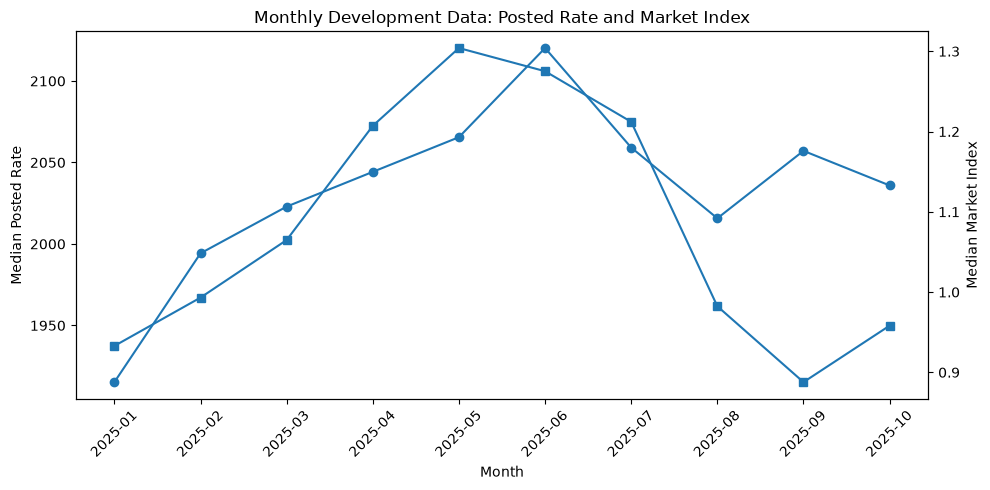

In [19]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(
    monthly_summary.index.astype(str),
    monthly_summary["median_rate"],
    marker="o",
    label="Median Posted Rate"
)

ax1.set_xlabel("Month")
ax1.set_ylabel("Median Posted Rate")
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()

ax2.plot(
    monthly_summary.index.astype(str),
    monthly_summary["median_market_index"],
    marker="s",
    label="Median Market Index"
)

ax2.set_ylabel("Median Market Index")

plt.title("Monthly Development Data: Posted Rate and Market Index")
plt.tight_layout()
plt.show()

## 8.2.1 Temporal Visualization Finding

The monthly visualization confirms visible temporal variation in both median `posted_rate` and median `market_index` during the January–October development period.

The two series show some periods of similar movement, particularly around the May–June increase and subsequent decline, but they do not move identically throughout the period. This visualization therefore supports investigating the relationship between these variables rather than assuming that `market_index` directly determines `posted_rate`.

## 9. Target Distribution

The prediction target, `posted_rate`, will be examined to understand its distribution, skewness, and concentration of extreme values.

This is exploratory only; no target transformation will be selected based solely on the visualization.

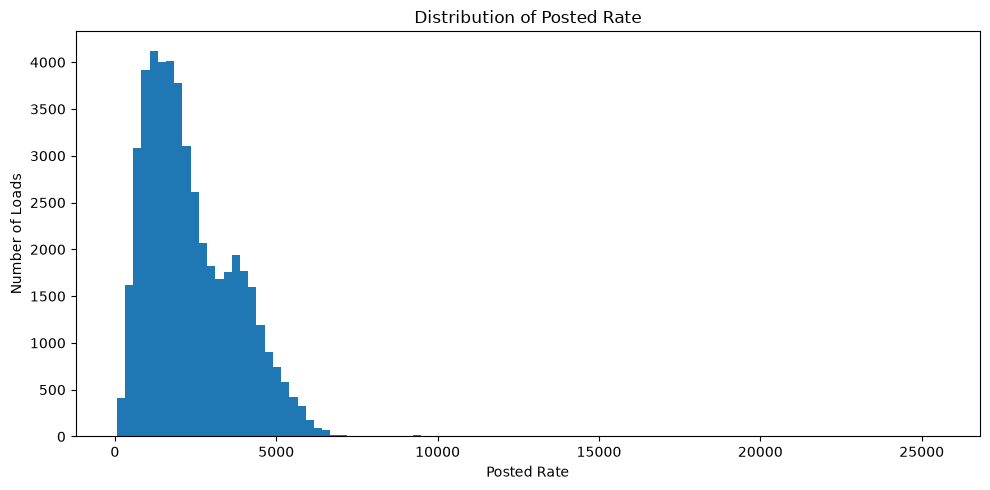

In [20]:
plt.figure(figsize=(10, 5))

plt.hist(train["posted_rate"], bins=100)

plt.xlabel("Posted Rate")
plt.ylabel("Number of Loads")
plt.title("Distribution of Posted Rate")

plt.tight_layout()
plt.show()

C:\Users\qasim\AppData\Local\Temp\ipykernel_21136\1032569010.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(train["posted_rate"], vert=False)


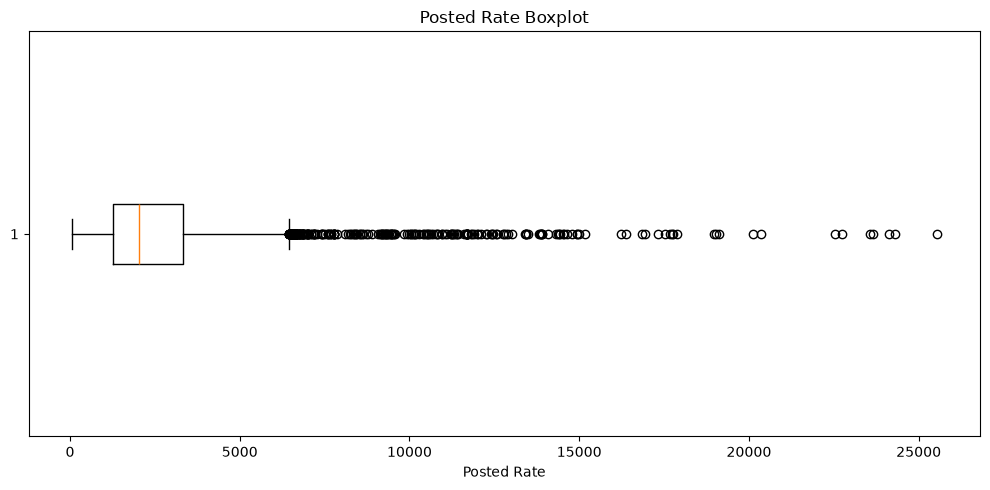

In [21]:
plt.figure(figsize=(10, 5))

plt.boxplot(train["posted_rate"], vert=False)

plt.xlabel("Posted Rate")
plt.title("Posted Rate Boxplot")

plt.tight_layout()
plt.show()

## 9.1 Target Distribution Findings

The `posted_rate` distribution is strongly right-skewed, with most observations concentrated in the lower-to-middle range and a long upper tail extending to 25,533.

The boxplot identifies numerous observations beyond the conventional statistical outlier boundaries. These observations are not automatically treated as erroneous because extreme freight rates may represent legitimate market or route conditions.

No target observations are removed, capped, or otherwise modified based solely on the observed distribution.

The pronounced skew will be considered during model development, including whether alternative target treatments improve validation performance.

## 10. Numerical Feature Relationships

This section examines the relationships between numerical features and `posted_rate`.

Correlation is used as an exploratory measure only. It does not establish causation and may not capture nonlinear relationships.

In [22]:
correlation_columns = [
    "distance",
    "weight",
    "market_index",
    "quote_signal",
    "posted_rate"
]

correlation_matrix = train[correlation_columns].corr()

print(correlation_matrix.round(3).to_string())

              distance  weight  market_index  quote_signal  posted_rate
distance         1.000   0.003        -0.002        -0.057        0.909
weight           0.003   1.000        -0.001         0.008        0.035
market_index    -0.002  -0.001         1.000        -0.068        0.034
quote_signal    -0.057   0.008        -0.068         1.000       -0.040
posted_rate      0.909   0.035         0.034        -0.040        1.000


## 10.1 Numerical Correlation Findings

The correlation analysis shows a strong positive linear relationship between `distance` and `posted_rate`, with a Pearson correlation of approximately 0.909.

The remaining numerical features have weak marginal linear correlations with the target:

- `weight`: approximately 0.035
- `market_index`: approximately 0.034
- `quote_signal`: approximately -0.040

The numerical predictors also show relatively weak pairwise correlations with one another.

These results indicate that `distance` is likely to be an important predictive feature. However, the weak marginal correlations of the other variables do not establish that they are uninformative, since nonlinear relationships and feature interactions are not captured by Pearson correlation alone.

Correlation is therefore used as an exploratory observation rather than as a basis for removing features.

## 10.2 Distance and Posted Rate Relationship

Because `distance` has the strongest numerical correlation with `posted_rate`, this relationship is examined visually to determine its shape and identify potential clusters or unusual observations.

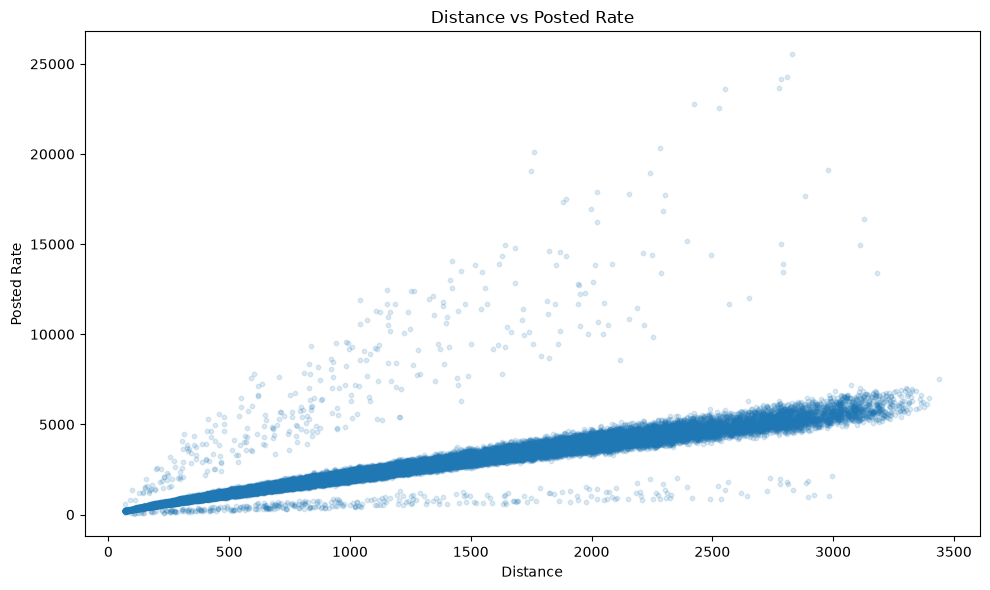

In [23]:
plt.figure(figsize=(10, 6))

plt.scatter(
    train["distance"],
    train["posted_rate"],
    alpha=0.15,
    s=10
)

plt.xlabel("Distance")
plt.ylabel("Posted Rate")
plt.title("Distance vs Posted Rate")

plt.tight_layout()
plt.show()

## 10.2.1 Distance and Posted Rate Findings

The scatter plot confirms a strong positive relationship between `distance` and `posted_rate`, consistent with the Pearson correlation of approximately 0.909.

However, the relationship is not represented by a single narrow linear band. The plot shows multiple regions of observations, including a dense central relationship, a lower-rate band, and a smaller group of substantially higher-rate observations.

The spread of posted rates also appears to increase at larger distances. Several observations have rates substantially above the dominant range, including values above 20,000.

These patterns indicate that distance is an important predictive variable but is unlikely to explain the target completely. Additional features, categorical effects, interactions, or nonlinear relationships may be important.

The extreme observations are retained because the visualization alone does not establish that they are erroneous.

## 10.3 Equipment and Posted Rate

Equipment type may influence freight pricing. This section compares posted-rate distributions across the three equipment categories and examines whether the distance-rate relationship differs by equipment type.

In [24]:
print("=== POSTED RATE BY EQUIPMENT ===")

equipment_summary = (
    train.groupby("equipment")["posted_rate"]
    .agg(["count", "mean", "median", "std", "min", "max"])
)

print(equipment_summary.to_string())

=== POSTED RATE BY EQUIPMENT ===
           count         mean    median          std     min       max
equipment                                                             
Dry Van    27202  2271.548686  1953.035  1423.029914   57.22  25533.00
Flatbed     8753  2445.087223  2076.810  1505.053087  157.76  17893.17
Reefer     12045  2553.636939  2196.670  1589.670824   63.36  24140.21


<Figure size 900x500 with 0 Axes>

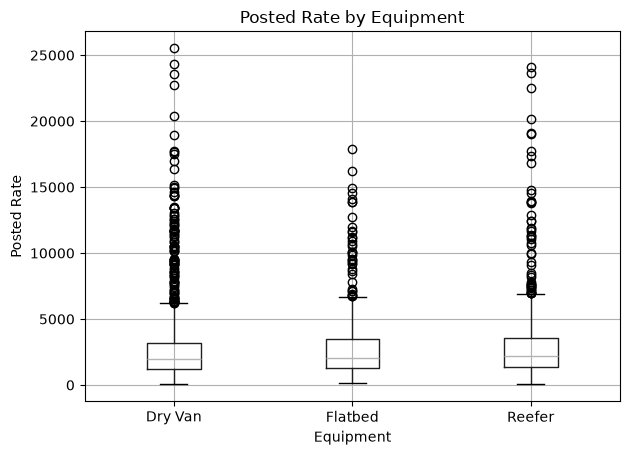

In [25]:
plt.figure(figsize=(9, 5))

train.boxplot(
    column="posted_rate",
    by="equipment"
)

plt.xlabel("Equipment")
plt.ylabel("Posted Rate")
plt.title("Posted Rate by Equipment")
plt.suptitle("")

plt.tight_layout()
plt.show()

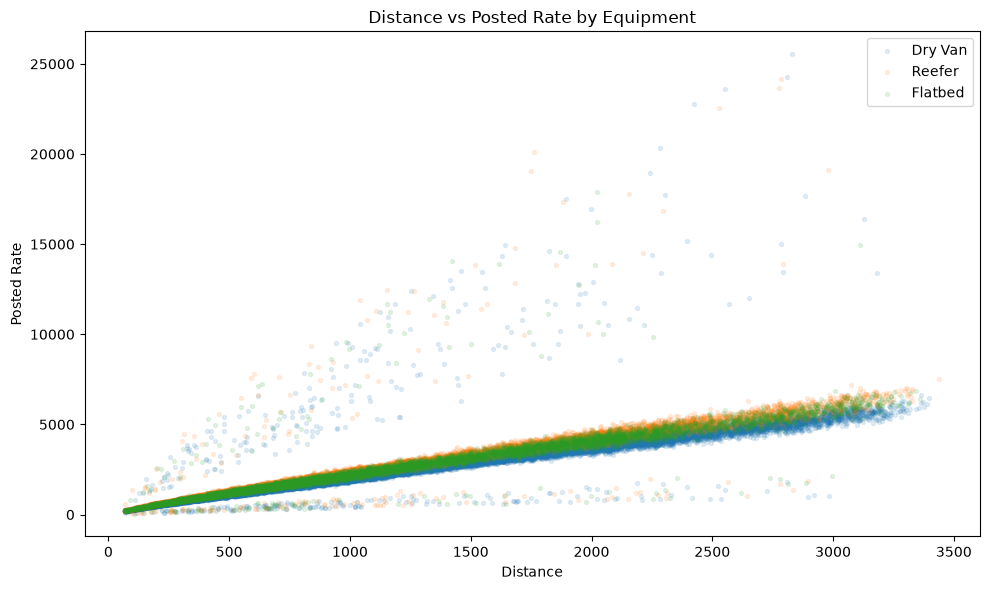

In [26]:
plt.figure(figsize=(10, 6))

for equipment_type in train["equipment"].unique():
    subset = train[train["equipment"] == equipment_type]

    plt.scatter(
        subset["distance"],
        subset["posted_rate"],
        alpha=0.12,
        s=8,
        label=equipment_type
    )

plt.xlabel("Distance")
plt.ylabel("Posted Rate")
plt.title("Distance vs Posted Rate by Equipment")
plt.legend()

plt.tight_layout()
plt.show()

## 10.3.1 Equipment and Posted Rate Findings

The equipment categories show differences in their posted-rate distributions.

The median posted rates are approximately:

- Dry Van: 1,953.04
- Flatbed: 2,276.81
- Reefer: 2,196.67

However, the distributions overlap substantially, and all three equipment categories contain high-rate observations.

The distance-versus-rate visualization also shows that the strong positive relationship between distance and posted rate is present across all three equipment categories. Equipment may therefore provide additional predictive information, but it does not appear to explain the overall distance-rate relationship by itself.

The analysis does not support removing any equipment category or treating the categories as interchangeable.

## 10.4 Rate per Mile Investigation

Because `distance` has a strong relationship with `posted_rate`, the implied rate per mile is examined as an exploratory measure.

This is not yet being introduced as a model feature. The purpose is to determine whether the different pricing patterns observed in the distance-rate relationship correspond to differences in rate per mile.

In [27]:
train_rate_analysis = train.copy()

train_rate_analysis["rate_per_mile"] = (
    train_rate_analysis["posted_rate"]
    / train_rate_analysis["distance"]
)

print("=== RATE PER MILE SUMMARY ===")
print(
    train_rate_analysis["rate_per_mile"]
    .describe()
    .to_string()
)

print("\n=== RATE PER MILE BY EQUIPMENT ===")
print(
    train_rate_analysis
    .groupby("equipment")["rate_per_mile"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .to_string()
)

=== RATE PER MILE SUMMARY ===
count    48000.000000
mean         2.215347
std          0.583887
min          0.333709
25%          1.986974
50%          2.145348
75%          2.342696
max         14.125294

=== RATE PER MILE BY EQUIPMENT ===
           count      mean    median       std       min        max
equipment                                                          
Dry Van    27202  2.115401  2.046203  0.538102  0.333709  12.816710
Flatbed     8753  2.294729  2.219683  0.610187  0.353881  12.949578
Reefer     12045  2.383376  2.311540  0.615467  0.386292  14.125294


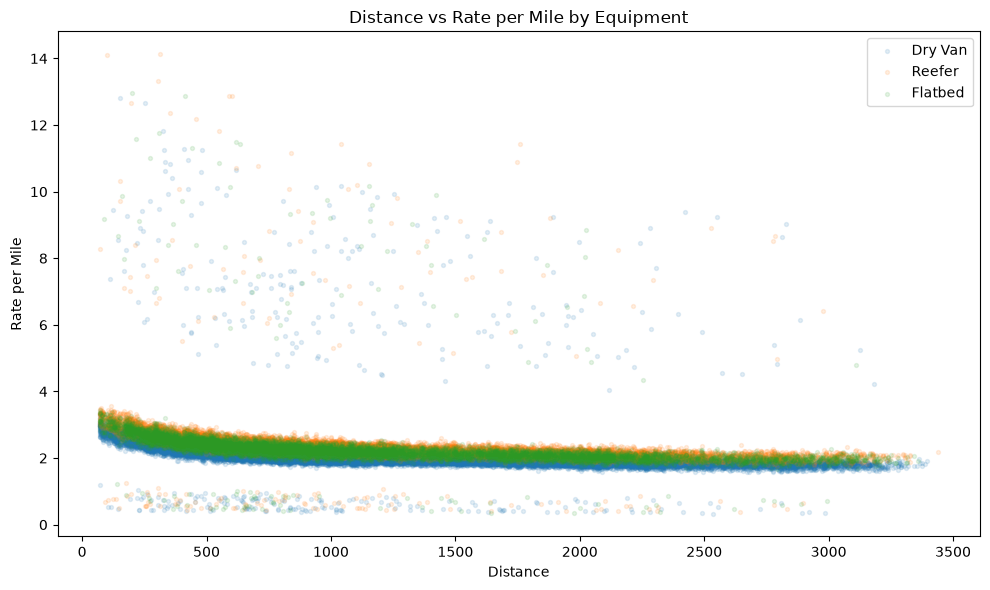

In [28]:
plt.figure(figsize=(10, 6))

for equipment_type in train_rate_analysis["equipment"].unique():
    subset = train_rate_analysis[
        train_rate_analysis["equipment"] == equipment_type
    ]

    plt.scatter(
        subset["distance"],
        subset["rate_per_mile"],
        alpha=0.12,
        s=8,
        label=equipment_type
    )

plt.xlabel("Distance")
plt.ylabel("Rate per Mile")
plt.title("Distance vs Rate per Mile by Equipment")
plt.legend()

plt.tight_layout()
plt.show()

## 10.4.1 Rate per Mile Findings

The rate-per-mile analysis provides additional insight into the relationship between distance and posted rate.

The dominant observations form a relatively narrow pricing band, with rate per mile generally decreasing as distance increases. Therefore, the relationship between total distance and posted rate is not equivalent to applying a constant rate per mile across all loads.

A separate group of observations has substantially higher rates per mile, particularly at shorter distances. This helps explain the multiple bands observed in the original distance-versus-rate visualization.

The median rate per mile also differs across equipment categories:

- Dry Van: approximately 2.046
- Flatbed: approximately 2.220
- Reefer: approximately 2.312

These observations suggest that nonlinear relationships and interactions between features may be relevant for predicting `posted_rate`. No modeling decision is made solely from this exploratory analysis.

## 10.5 Market Index and Quote Signal Relationships

`market_index` and `quote_signal` have weak marginal Pearson correlations with `posted_rate`. This section examines their distributions and relationships with the target to determine whether nonlinear or conditional patterns may be present.

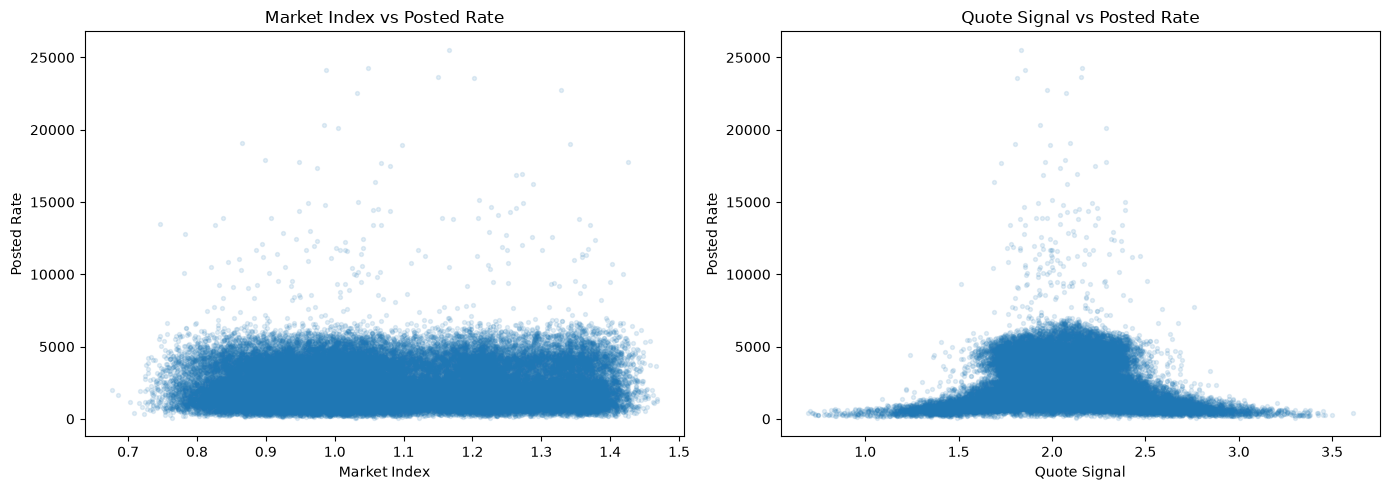

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(
    train["market_index"],
    train["posted_rate"],
    alpha=0.12,
    s=8
)
axes[0].set_xlabel("Market Index")
axes[0].set_ylabel("Posted Rate")
axes[0].set_title("Market Index vs Posted Rate")

axes[1].scatter(
    train["quote_signal"],
    train["posted_rate"],
    alpha=0.12,
    s=8
)
axes[1].set_xlabel("Quote Signal")
axes[1].set_ylabel("Posted Rate")
axes[1].set_title("Quote Signal vs Posted Rate")

plt.tight_layout()
plt.show()

In [30]:
print("=== FEATURE DISTRIBUTIONS ===")

print("\nMarket Index:")
print(train["market_index"].describe().to_string())

print("\nQuote Signal:")
print(train["quote_signal"].describe().to_string())

=== FEATURE DISTRIBUTIONS ===

Market Index:
count    47626.000000
mean         1.083387
std          0.168091
min          0.676390
25%          0.949670
50%          1.055800
75%          1.219590
max          1.467780

Quote Signal:
count    48000.000000
mean         2.062468
std          0.291391
min          0.692280
25%          1.891030
50%          2.055750
75%          2.221685
max          3.610350


## 10.5.1 Market Index and Quote Signal Findings

The `market_index` visualization does not show an obvious strong marginal relationship with `posted_rate`, consistent with its weak Pearson correlation of approximately 0.034.

The `quote_signal` visualization shows a substantially different pattern. Although its Pearson correlation with `posted_rate` is approximately -0.040, the scatter plot suggests a nonlinear relationship. Higher posted rates are concentrated more strongly around the middle portion of the `quote_signal` range, while observations toward the lower and upper extremes generally have lower rates.

This demonstrates that weak linear correlation does not necessarily imply weak predictive value. Nonlinear relationships will therefore be considered during model development.

No features are removed based on correlation alone.

## 10.5.2 Quote Signal by Rate Distribution

To quantify the nonlinear pattern observed in the scatter plot, `quote_signal` is divided into quantile-based groups and the posted-rate distribution is summarized within each group.

In [31]:
quote_bins = pd.qcut(
    train["quote_signal"],
    q=10,
    duplicates="drop"
)

quote_summary = (
    train.assign(quote_bin=quote_bins)
    .groupby("quote_bin", observed=True)["posted_rate"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        std="std"
    )
)

print(quote_summary.to_string())

                count         mean    median          std
quote_bin                                                
(0.691, 1.735]   4800  1473.648881  1038.495  1252.530095
(1.735, 1.851]   4801  2598.360702  2304.070  1536.810925
(1.851, 1.928]   4799  2679.470338  2430.050  1390.890112
(1.928, 1.994]   4800  2640.319573  2297.865  1449.692529
(1.994, 2.056]   4803  2639.470679  2297.590  1373.572250
(2.056, 2.118]   4797  2635.321910  2270.130  1448.727380
(2.118, 2.185]   4800  2665.780252  2353.040  1443.650301
(2.185, 2.266]   4800  2674.993746  2401.185  1448.676776
(2.266, 2.403]   4800  2469.526812  2051.335  1554.457268
(2.403, 3.61]    4800  1262.928235   987.465   982.611252


## 10.5.3 Quote Signal Binned Findings

The quantile-based analysis confirms a nonlinear relationship between `quote_signal` and `posted_rate`.

Median posted rates increase from approximately 1,474 in the lowest quote-signal bin to approximately 2,670 around the middle of the distribution, before declining toward approximately 1,263 in the highest bin.

The relationship is therefore approximately low-to-high-to-low rather than monotonic. This helps explain why the overall Pearson correlation is close to zero despite the feature showing structured variation in the target.

The result reinforces that marginal linear correlation alone is insufficient for feature-selection decisions.

## 11. Feature Availability Across Prediction Datasets

The assessment requires predictions for both the 12,000-row validation dataset and the 31-row December chart input dataset.

This section compares the features available in the development, validation, and December prediction datasets. The purpose is to identify features that cannot be supplied directly for every required prediction.

In [32]:
print("=== FEATURE AVAILABILITY ===")

train_features = set(train.columns) - {"posted_rate"}
validation_features = set(validation.columns)
december_features = set(december.columns) - {"predicted_rate"}

print("Train features:")
print(sorted(train_features))

print("\nValidation features:")
print(sorted(validation_features))

print("\nDecember prediction features:")
print(sorted(december_features))

print("\n=== MISSING FROM DECEMBER ===")
print(
    sorted(validation_features - december_features)
)

print("\n=== AVAILABLE IN ALL THREE ===")
print(
    sorted(train_features & validation_features & december_features)
)

=== FEATURE AVAILABILITY ===
Train features:
['date', 'delivery', 'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'load_id', 'market_index', 'pickup', 'pickup_lat', 'pickup_lon', 'quote_signal', 'weight']

Validation features:
['date', 'delivery', 'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'load_id', 'market_index', 'pickup', 'pickup_lat', 'pickup_lon', 'quote_signal', 'weight']

December prediction features:
['date', 'delivery', 'distance', 'equipment', 'pickup', 'weight']

=== MISSING FROM DECEMBER ===
['delivery_lat', 'delivery_lon', 'load_id', 'market_index', 'pickup_lat', 'pickup_lon', 'quote_signal']

=== AVAILABLE IN ALL THREE ===
['date', 'delivery', 'distance', 'equipment', 'pickup', 'weight']


## 11.1 Feature Availability Findings

The comparison of prediction datasets shows that the following features are available in all three datasets:

- `date`
- `pickup`
- `delivery`
- `distance`
- `equipment`
- `weight`

The development and validation datasets additionally contain:

- `pickup_lat`
- `pickup_lon`
- `delivery_lat`
- `delivery_lon`
- `market_index`
- `quote_signal`

These additional features are not present in the December chart input dataset.

The assessment materials do not specify how `market_index` or `quote_signal` should be obtained for the December inputs, nor do they explicitly establish their availability at prediction time. Therefore, no assumptions are made about reconstructing these features at this stage.

Feature selection for the final prediction pipeline will consider the requirement that predictions must be generated for both the validation and December datasets.

In [33]:
print("=== WEIGHT AVAILABILITY BY DATASET ===")

print("\nTrain:")
print(train["weight"].isna().value_counts().rename({
    False: "present",
    True: "missing"
}).to_string())

print("\nValidation:")
print(validation["weight"].isna().value_counts().rename({
    False: "present",
    True: "missing"
}).to_string())

print("\nDecember:")
print(december["weight"].isna().value_counts().rename({
    False: "present",
    True: "missing"
}).to_string())


print("\n=== MISSING WEIGHT BY EQUIPMENT ===")

print("\nTrain:")
print(
    pd.crosstab(
        train["equipment"],
        train["weight"].isna(),
        normalize="index"
    ).rename(columns={
        False: "weight_present",
        True: "weight_missing"
    }).to_string()
)

print("\nValidation:")
print(
    pd.crosstab(
        validation["equipment"],
        validation["weight"].isna(),
        normalize="index"
    ).rename(columns={
        False: "weight_present",
        True: "weight_missing"
    }).to_string()
)


print("\n=== DECEMBER WEIGHT ===")
print(december["weight"].describe().to_string())

print("\nDecember weight values:")
print(december["weight"].unique())

=== WEIGHT AVAILABILITY BY DATASET ===

Train:
weight
present    47700
missing      300

Validation:
weight
present    11835
missing      165

December:
weight
present    31

=== MISSING WEIGHT BY EQUIPMENT ===

Train:
weight     weight_present  weight_missing
equipment                                
Dry Van          0.993567        0.006433
Flatbed          0.993716        0.006284
Reefer           0.994188        0.005812

Validation:
weight     weight_present  weight_missing
equipment                                
Dry Van          0.985103        0.014897
Flatbed          0.987091        0.012909
Reefer           0.988201        0.011799

=== DECEMBER WEIGHT ===
count       31.0
mean     32000.0
std          0.0
min      32000.0
25%      32000.0
50%      32000.0
75%      32000.0
max      32000.0

December weight values:
[32000]


## 11.2 Weight Availability Findings

`weight` is missing in 300 of the 48,000 development observations (0.625%) and 165 of the 12,000 validation observations (1.375%).

All 31 December chart-input records contain a weight value. The December weight is 32,000 for every required prediction.

The missing-weight rate is relatively small in both development and validation data. Missingness is present across the equipment categories rather than being confined to a single category.

The appropriate treatment of missing `weight` values will be evaluated during model development rather than assumed during profiling.

## 11.3 Missing Market Index Investigation

`market_index` contains missing observations in both the development and validation datasets. This section examines whether records with missing `market_index` have materially different target-rate distributions from records where the feature is available.

This analysis is descriptive and does not yet determine how the feature will be handled during modeling.

In [34]:
market_missing = train["market_index"].isna()

print("=== MARKET INDEX MISSINGNESS ===")

print(f"Missing:    {market_missing.sum()}")
print(f"Present:    {(~market_missing).sum()}")

print("\nTarget comparison:")

market_target_comparison = pd.DataFrame({
    "market_index_missing": train.loc[
        market_missing, "posted_rate"
    ].describe(),
    "market_index_present": train.loc[
        ~market_missing, "posted_rate"
    ].describe()
})

print(market_target_comparison.to_string())

=== MARKET INDEX MISSINGNESS ===
Missing:    374
Present:    47626

Target comparison:
       market_index_missing  market_index_present
count            374.000000          47626.000000
mean            2392.115107           2373.838275
std             1434.640755           1486.906945
min              207.710000             57.220000
25%             1254.287500           1251.545000
50%             2081.100000           2030.095000
75%             3294.790000           3331.015000
max             9454.940000          25533.000000


In [35]:
print("\n=== MISSING MARKET INDEX BY MONTH ===")

train_market_temp = train.copy()
train_market_temp["date_parsed"] = pd.to_datetime(
    train_market_temp["date"]
)

monthly_market_missing = (
    train_market_temp
    .groupby(train_market_temp["date_parsed"].dt.to_period("M"))
    ["market_index"]
    .apply(lambda x: x.isna().mean() * 100)
)

print(monthly_market_missing.to_string())


=== MISSING MARKET INDEX BY MONTH ===
date_parsed
2025-01    0.732005
2025-02    0.830067
2025-03    0.873709
2025-04    0.643287
2025-05    0.875229
2025-06    0.878110
2025-07    0.732899
2025-08    0.693423
2025-09    0.663812
2025-10    0.865444
Freq: M


## 11.4 Market Index Missingness Findings

`market_index` is missing in 374 of the 48,000 development observations, representing approximately 0.78% of the dataset. The missingness rate remains relatively stable across the January–October development period, ranging approximately from 0.64% to 0.87% by month.

The target distribution differs somewhat between observations with missing and observed `market_index` values. The median `posted_rate` is 2,081.00 for the missing group compared with 1,846.91 for the observed group, while the mean rates are 2,392.11 and 2,373.83 respectively.

The maximum target value is also substantially lower in the missing group (9,454.90 versus 25,533.00).

These differences indicate that missingness should not automatically be assumed to be completely unrelated to the target. However, the missing proportion is small, and the appropriate treatment will be evaluated during model development.

## 12. Daily Observation Coverage

Before designing the development validation strategy, we examine the number of labeled observations available per day across the development period.

In [36]:
daily_counts = (
    train.assign(
        date_parsed=pd.to_datetime(train["date"])
    )
    .groupby("date_parsed")
    .size()
)

print("=== DAILY DEVELOPMENT COVERAGE ===")
print(f"Number of development days: {daily_counts.shape[0]}")
print(f"Minimum loads/day: {daily_counts.min()}")
print(f"Median loads/day: {daily_counts.median()}")
print(f"Mean loads/day: {daily_counts.mean():.2f}")
print(f"Maximum loads/day: {daily_counts.max()}")

print("\nDaily count percentiles:")
print(
    daily_counts.quantile(
        [0, 0.01, 0.25, 0.50, 0.75, 0.99, 1.00]
    ).to_string()
)

=== DAILY DEVELOPMENT COVERAGE ===
Number of development days: 304
Minimum loads/day: 115
Median loads/day: 157.0
Mean loads/day: 157.89
Maximum loads/day: 198

Daily count percentiles:
0.00    115.00
0.01    131.03
0.25    150.00
0.50    157.00
0.75    166.00
0.99    188.97
1.00    198.00


## 12.1 Daily Coverage Findings

The development dataset contains 304 days of observations from January through October 2025.

Daily load volume is relatively consistent:

- Minimum: 115 loads
- 25th percentile: 150 loads
- Median: 157 loads
- Mean: 157.89 loads
- 75th percentile: 166 loads
- Maximum: 198 loads

The relatively stable daily observation volume provides sufficient observations for creating temporally ordered validation periods within the development dataset.

## 13. Geographic Feature Reconstructability

The December prediction inputs do not contain latitude and longitude, although the development and validation datasets do.

Before considering geographic features for the final prediction pipeline, we will determine whether the supplied development data provides a consistent mapping between city names and coordinates.

Only a deterministic mapping supported by the supplied data will be considered for reconstructing coordinates for December predictions.

In [38]:
print("=== COORDINATE CONSISTENCY ===")

pickup_multi = pickup_coordinate_check[
    (pickup_coordinate_check["unique_lat"] > 1) |
    (pickup_coordinate_check["unique_lon"] > 1)
]

delivery_multi = delivery_coordinate_check[
    (delivery_coordinate_check["unique_lat"] > 1) |
    (delivery_coordinate_check["unique_lon"] > 1)
]

print(f"Pickup cities: {len(pickup_coordinate_check)}")
print(f"Pickup cities with multiple coordinates: {len(pickup_multi)}")

print(f"\nDelivery cities: {len(delivery_coordinate_check)}")
print(f"Delivery cities with multiple coordinates: {len(delivery_multi)}")

print("\nPickup cities with multiple coordinates:")
print(
    pickup_multi.index.tolist()
    if len(pickup_multi) > 0
    else "None"
)

print("\nDelivery cities with multiple coordinates:")
print(
    delivery_multi.index.tolist()
    if len(delivery_multi) > 0
    else "None"
)

=== COORDINATE CONSISTENCY ===
Pickup cities: 64
Pickup cities with multiple coordinates: 0

Delivery cities: 64
Delivery cities with multiple coordinates: 0

Pickup cities with multiple coordinates:
None

Delivery cities with multiple coordinates:
None


# 14. Profiling Summary

The initial profiling established the following characteristics of the assessment data:

### Data structure

- 48,000 labeled development observations covering January–October 2025.
- 12,000 validation observations covering November–December 2025.
- 31 December chart-input observations covering December 2025.

### Data quality

- No duplicate rows or duplicate `load_id` values were identified.
- `weight` contains 300 missing observations and 292 negative observations in the development data.
- The negative-weight observations were investigated and found to occur across all three equipment categories and throughout the development period. Their absolute values overlap substantially with the positive-weight distribution, but the correct interpretation of the negative sign could not be established from the supplied data alone.
- `market_index` contains 374 missing observations in the development data.
- `distance` and `posted_rate` contain only positive, non-missing values.
- No source data has been modified during profiling.

### Target behavior

- `posted_rate` is strongly right-skewed.
- A long upper tail contains observations substantially above the dominant rate range.
- Extreme observations have been retained because exploratory analysis does not establish that they are erroneous.
- The strong relationship between `distance` and `posted_rate` is not represented by a single narrow linear pattern; multiple pricing bands are visible.

### Feature relationships

- `distance` has a strong positive linear relationship with `posted_rate` (Pearson correlation ≈ 0.909).
- Equipment categories show differences in rate distributions but substantial overlap.
- Rate per mile generally decreases as distance increases, indicating that a constant rate-per-mile assumption would not adequately describe the data.
- `quote_signal` has near-zero Pearson correlation with the target but shows a nonlinear relationship when examined visually and by quantile-based groups.
- `market_index` has a weak marginal linear relationship with the target.
- Correlation alone has therefore not been used to remove features.

### Geographic and categorical coverage

- The development data contains 64 unique pickup cities and 64 unique delivery cities.
- Each development pickup city maps to one unique latitude/longitude pair, and each development delivery city also maps to one unique latitude/longitude pair.
- Validation contains 72 pickup and 72 delivery cities.
- Eight validation cities are unseen during development: Allentown, Charlotte, Chicago, Jackson, Knoxville, Laredo, Norfolk, and San Diego.
- The validation data contains 4,214 unique routes, of which 736 (17.47%) were not observed during development.
- 1,461 of 12,000 validation loads (12.17%) belong to unseen routes.

### Temporal structure

- Validation occurs strictly after the development period.
- Monthly target and feature distributions vary over time.
- Development data contains 304 days with relatively stable daily observation volume, ranging from 115 to 198 loads per day.
- The temporal ordering of the data should therefore be preserved when evaluating model generalization.

### Prediction constraints

The December prediction inputs provide:

- `date`
- `pickup`
- `delivery`
- `distance`
- `equipment`
- `weight`

They do not provide:

- `pickup_lat`
- `pickup_lon`
- `delivery_lat`
- `delivery_lon`
- `market_index`
- `quote_signal`

The development data provides a deterministic city-to-coordinate mapping for the 64 cities observed during development. This may allow geographic features to be reconstructed for cities covered by that mapping, although validation contains eight cities not present in the development mapping.

`market_index` and `quote_signal` cannot currently be reconstructed for December from the supplied data without introducing an unsupported assumption. Their use in the final prediction pipeline therefore requires further consideration.

### Profiling conclusion

The profiling indicates that the prediction problem has strong temporal structure, substantial dependence on distance, nonlinear feature relationships, missing and unusual weight values, and a meaningful requirement for generalization to unseen routes and some unseen locations.

No modeling decisions have been made solely from exploratory statistics. The next phase will define a temporally appropriate validation strategy and establish which feature representations can be used consistently for all required predictions.

# 15. Validation Strategy

## 15.1 Validation Objective

The supplied validation dataset represents a future period relative to the labeled development data. The development data covers January–October 2025, while the supplied validation data covers November–December 2025.

The purpose of internal validation is therefore to estimate how well a model can generalize to future observations while preserving the temporal ordering of the data.

The internal validation strategy should:

- prevent future observations from being used to predict earlier observations;
- provide multiple opportunities to evaluate model generalization;
- use only information that would have been available at the time of each validation period;
- support comparison of alternative feature representations and models;
- remain reproducible and straightforward to explain in the final assessment report.

## 15.2 Why Random Splitting Is Not Used

A random train-validation split is not selected as the primary validation strategy.

Random splitting would mix observations from different points in time. For example, observations from later months could be included in the training set while earlier observations are used for validation.

This would not reproduce the structure of the actual prediction task, where the model is trained on January–October data and then asked to predict a later period.

Because the development and supplied validation datasets are temporally ordered, internal validation will also preserve temporal ordering.

## 15.3 Expanding-Window Forward Validation

An expanding-window validation strategy will be used.

For each fold, the model will be trained only on observations occurring before the validation period. After each fold, the training window expands to include the preceding validation period.

The proposed structure is:

| Fold | Training Period | Validation Period |
|------|-----------------|-------------------|
| 1 | January–June 2025 | July 2025 |
| 2 | January–July 2025 | August 2025 |
| 3 | January–August 2025 | September 2025 |
| 4 | January–September 2025 | October 2025 |

This produces four chronological one-month-ahead validation folds.

The approach provides multiple estimates of forward generalization while ensuring that no validation observation is used to train a model for an earlier period.

The final supplied validation dataset (November–December 2025) remains completely untouched during internal model selection.

## 15.4 Evaluation Metrics

Internal model comparisons will use regression metrics calculated on each forward-validation fold.

Mean Absolute Error (MAE) will be used as the primary comparison metric because it expresses prediction error directly in the same units as `posted_rate` and gives each observation equal weight.

Root Mean Squared Error (RMSE) will be tracked as a secondary metric because it places greater emphasis on large prediction errors. This is particularly relevant given the long right tail observed in `posted_rate`.

Metrics will be calculated separately for each fold and summarized across folds rather than relying on a single validation period.

## 15.5 Leakage Prevention

All preprocessing and feature transformations that learn information from the data will be fitted using only the training portion of each fold.

The corresponding validation period will be transformed using parameters or mappings learned from the training period.

The validation target will not be used during preprocessing, feature engineering, model fitting, or hyperparameter selection.

The final November–December supplied validation dataset will not be used to select models or tune hyperparameters.

## 15.6 Feature Availability Policy

Two feature sets will initially be evaluated.

### Candidate A — Common Prediction Features

The baseline feature set will contain only variables available in all required prediction datasets:

- `date`
- `pickup`
- `delivery`
- `distance`
- `equipment`
- `weight`

This provides a complete feature pipeline for both the supplied validation predictions and the required December predictions.

### Candidate B — Common Features + Geographic Information

A second candidate will investigate the addition of geographic coordinates:

- `pickup_lat`
- `pickup_lon`
- `delivery_lat`
- `delivery_lon`

The development data shows that each of its 64 pickup cities and 64 delivery cities has a unique coordinate pair, providing a deterministic city-to-coordinate mapping for locations represented in development.

The supplied validation dataset contains coordinates directly, including for its eight cities that are unseen in the development city categories.

For the December prediction inputs, coordinates are not supplied. Geographic reconstruction will therefore only be performed where a city has a verified mapping from the development data. The December route will be checked explicitly before using geographic features in the final pipeline.

`market_index` and `quote_signal` will not be included in the initial common prediction pipeline because they are absent from the December prediction inputs and the supplied assessment materials do not provide a method for reconstructing them for December.

Alternative use of these variables will only be considered if a defensible prediction-time construction method is established from the supplied data.

## 15.7 Validation Experiment Plan

The initial modeling experiments will compare candidate feature representations under the same expanding-window validation folds.

The first comparison will be:

1. Common prediction features.
2. Common prediction features plus geographic coordinates.

For each candidate feature set, alternative preprocessing and model configurations will be evaluated using the same temporal folds and evaluation metrics.

Each experiment will record:

- feature set;
- preprocessing approach;
- model;
- validation folds;
- MAE by fold;
- RMSE by fold;
- mean and variation across folds;
- relevant observations or failure cases.

Model selection will be based on validation evidence rather than a single fold or a single metric.

The final model will then be retrained using the complete January–October development dataset before generating predictions for the untouched November–December validation dataset and the required December chart inputs.

## 15.8 Assessment of the Validation Design

The expanding-window approach is selected because it most closely reproduces the temporal nature of the supplied prediction task while allowing multiple historical forward-validation tests.

The design avoids random temporal mixing, preserves chronological ordering, keeps the supplied November–December validation data untouched during model selection, and provides a consistent framework for comparing feature representations and models.

## 15.9 December Geographic Coverage Check

Before geographic features are included in the final prediction pipeline, the December prediction route is checked against the coordinate mappings learned from the development data.

This verifies whether the required December inputs can be assigned coordinates using only information supplied in the assessment data.

In [39]:
print("=== DECEMBER CITY COORDINATE COVERAGE ===")

train_pickup_cities = set(train["pickup"].unique())
train_delivery_cities = set(train["delivery"].unique())

december_pickup_cities = set(december["pickup"].unique())
december_delivery_cities = set(december["delivery"].unique())

print("December pickup cities:", december_pickup_cities)
print("December delivery cities:", december_delivery_cities)

print("\nPickup cities missing from development mapping:")
print(
    sorted(december_pickup_cities - train_pickup_cities)
    or "None"
)

print("\nDelivery cities missing from development mapping:")
print(
    sorted(december_delivery_cities - train_delivery_cities)
    or "None"
)

=== DECEMBER CITY COORDINATE COVERAGE ===
December pickup cities: {'Lexington'}
December delivery cities: {'Fort Wayne'}

Pickup cities missing from development mapping:
None

Delivery cities missing from development mapping:
None


In [40]:
print("\n=== DECEMBER ROUTE ===")
print(
    december[["pickup", "delivery"]]
    .drop_duplicates()
    .to_string(index=False)
)


=== DECEMBER ROUTE ===
   pickup   delivery
Lexington Fort Wayne


### 15.9.1 December Geographic Coverage Finding

The fixed December prediction route is Lexington → Fort Wayne. Both cities are present in the development data and have verified coordinate mappings.

Therefore, geographic features (pickup and delivery latitude/longitude) can be reconstructed for the December prediction inputs without relying on external geographic data.

This makes the geographic feature set deployable for the required December prediction scenario.